# 🔁 State Transition Analysis

This notebook visualizes all state transitions from the system including reasons and timestamps.

It includes:
- A preview of the transitions
- A timeline plot with transition reasons and states

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("state_transition_log.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp")

# Preview the data
df[["timestamp", "from", "to", "reason"]]


,timestamp,from,to,reason
0,2025-05-31 23:17:46.709107+00:00,start,preprocessing,start of program
1,2025-05-31 23:17:46.726522+00:00,start,preprocess,kickoff
2,2025-05-31 23:17:46.730523+00:00,start,code_stability,initial stability check
3,2025-05-31 23:17:47.469838+00:00,code_stability,generate,"initial stability passed, now generate"
4,2025-05-31 23:17:51.234955+00:00,generate,code_stability,post-generation stability check
5,2025-05-31 23:17:51.633061+00:00,code_stability,discriminate,"post-generation stability passed, now discrimi..."
6,2025-05-31 23:17:51.646589+00:00,discriminate,generate,discriminator rejected—retry generate
7,2025-05-31 23:17:55.347242+00:00,generate,code_stability,post-generation stability check
8,2025-05-31 23:17:55.762390+00:00,code_stability,discriminate,"post-generation stability passed, now discrimi..."
9,2025-05-31 23:17:55.791860+00:00,discriminate,end,discriminator accepted the change


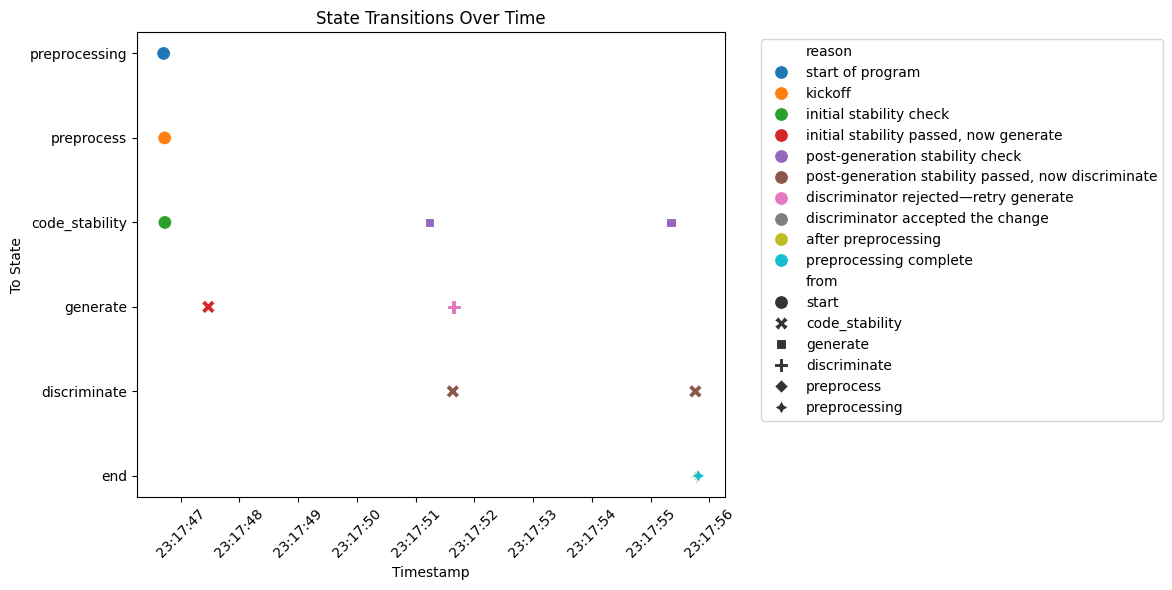

In [2]:
# Plot transitions over time
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="timestamp",
    y="to",
    hue="reason",
    style="from",
    s=100,
    palette="tab10"
)
plt.title("State Transitions Over Time")
plt.xlabel("Timestamp")
plt.ylabel("To State")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
